# solar

Each row is an annual measurement of solar power capacity. Columns are:
- `entity` name of a location
- `code` some kind of location code? 不知道
- `year` year when capacity was measured
- `solar` total capacity in gigawatts

## project ideas

- I plotted solar capacity for continents. Copy this notebook, then change it to show countries in 1 continent. Which countries have the most solar power capacity? Do you see any trends?

- Copy this notebook, then change it to use the `hydro` or `wind` dataset in the `science/data/energy` folder. Which continents (or countries) have the most hydro or wind power capacity?

In [11]:
from pathlib import Path
import pandas as pd

In [12]:
# Where is the dataset on your computer?
DATA_DIR = Path.cwd().parent / "data"
DATA_PATH = DATA_DIR / "energy/solar/data.csv"
print(f"The dataset is here: {DATA_PATH}")

The dataset is here: /Users/void/code/chengdu/science/data/energy/solar/data.csv


In [13]:
def cleanstr(values):
    # Convert strings to lowercase without whitespace.
    return [x.lower().replace(' ', '_').strip() for x in values]

In [14]:
# Read raw data
solar = pd.read_csv(DATA_PATH)
print(f"{len(solar)} rows loaded")

# Normalize column names
solar.columns = cleanstr(solar.columns)

solar

4240 rows loaded


,entity,code,year,solar
0,Afghanistan,AFG,2009,0.000002
1,Afghanistan,AFG,2010,0.000102
2,Afghanistan,AFG,2011,0.000120
3,Afghanistan,AFG,2012,0.016122
4,Afghanistan,AFG,2013,0.016843
...,...,...,...,...
4235,Zimbabwe,ZWE,2020,0.014154
4236,Zimbabwe,ZWE,2021,0.027584
4237,Zimbabwe,ZWE,2022,0.040449
4238,Zimbabwe,ZWE,2023,0.046175


In [15]:
# Check data types
solar.dtypes

entity        str
code          str
year        int64
solar     float64
dtype: object

In [16]:
# Count null markers in each column
solar.isnull().sum()

entity      0
code      275
year        0
solar       0
dtype: int64

In [17]:
# The 'entity' column has many different location types.
# For now, I'll only look at continents.
continents = [
    "Africa",
    "Asia",
    "Europe",
    "North America",
    "Oceania",
    "South America",
]
solar = solar.loc[solar['entity'].isin(continents)]
solar

,entity,code,year,solar
16,Africa,NaN,2000,0.008355
17,Africa,NaN,2001,0.009910
18,Africa,NaN,2002,0.011576
19,Africa,NaN,2003,0.013419
20,Africa,NaN,2004,0.016116
...,...,...,...,...
3529,South America,NaN,2020,13.435653
3530,South America,NaN,2021,21.353413
3531,South America,NaN,2022,34.770733
3532,South America,NaN,2023,49.844120


In [18]:
# This dataset is an example of a "tall" table.
# I want a "wide" table where each row is 1 year
# and each column is capacity for 1 continent.
widesolar = (
    solar
    .set_index(["year", "entity"])
    ['solar'].unstack()
)
widesolar

entity,Africa,Asia,Europe,North America,Oceania,South America
year,,,,,,
2000,0.008355,0.369045,0.202394,0.611100,0.025960,0.003283
2001,0.009910,0.505004,0.303503,0.477140,0.030427,0.004781
2002,0.011576,0.710955,0.389965,0.476533,0.035584,0.005946
2003,0.013419,0.949833,0.629146,0.701029,0.041144,0.007254
2004,0.016116,1.238988,1.342187,0.772512,0.048349,0.008097
2005,0.019012,1.609992,2.325967,0.903569,0.054788,0.008850
2006,0.024127,1.971657,3.290137,1.125672,0.064201,0.009816
2007,0.030395,2.296321,5.064379,1.473418,0.079165,0.011996
2008,0.037190,2.881439,10.544130,1.660481,0.091941,0.013744


<Axes: title={'center': 'installed solar capacity'}, xlabel='year', ylabel='gigawatts'>

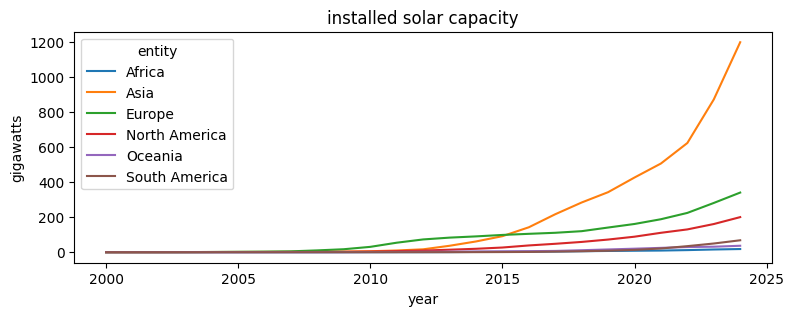

In [19]:
# Plot each column as a line.
plotkw = {
    "title" : "installed solar capacity",
    "ylabel" : "gigawatts",
    "figsize" : (9,3)
}
widesolar.plot(**plotkw)

<Axes: title={'center': 'installed solar capacity'}, xlabel='year', ylabel='gigawatts'>

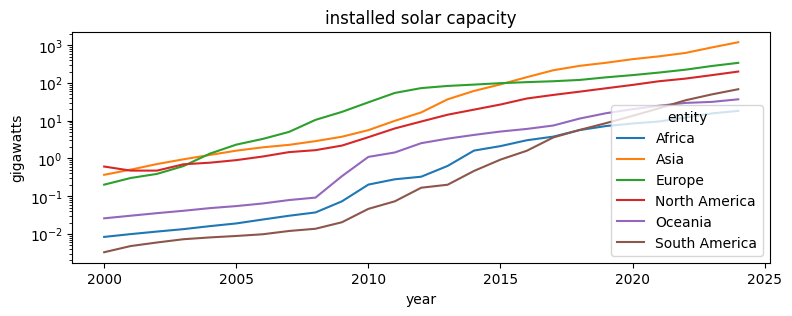

In [20]:
# That last plot looks like exponential growth.
# Try again with a logarithmic y-axis scale.
widesolar.plot(logy=True, **plotkw)